        STEP 1
        Dataset + Tokenization
                ↓
        STEP 2
        Token Embedding
        +
        Positional Encoding
                ↓
        STEP 3  ← NEXT
        Multi-Head Self-Attention
                ↓
        STEP 4
        Feed-Forward + LayerNorm + Residual
                ↓
        STEP 5
        Complete Transformer Block
                ↓
        STEP 6
        Language Model + Training
                ↓
        STEP 7
        Text Generation + Evaluation
                ↓
        STEP 8
        Attention Visualization + Results

## Step 1 — Set up the project and prepare the dataset

    Raw Text
       ↓
    Character-level Tokenization
       ↓
    Train / Validation Split
       ↓
    Input–Target Sequences
       ↓
    Transformer
       ↓
    Next-token Prediction

In [2]:
# ============================================
# TRANSFORMER FROM SCRATCH
# Step 1: Environment Setup
# ============================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import random
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.11.0+cu128
CUDA available: True
Using device: cuda


In [3]:
# Download Tiny Shakespeare dataset

import urllib.request

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

urllib.request.urlretrieve(url, "input.txt")

with open("input.txt", "r", encoding="utf-8") as f:
    text = f.read()

print("Dataset loaded successfully!")
print("Number of characters:", len(text))
print("\nFirst 500 characters:\n")
print(text[:500])

Dataset loaded successfully!
Number of characters: 1115394

First 500 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


### Inspect the dataset

In [4]:
print("Total characters:", len(text))
print("Unique characters:", len(set(text)))

print("\nCharacter vocabulary:")
print(sorted(set(text)))

Total characters: 1115394
Unique characters: 65

Character vocabulary:
['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


### Create the tokenizer

In [5]:
# ============================================
# Character-level tokenizer
# ============================================

chars = sorted(list(set(text)))

vocab_size = len(chars)

# Character → integer
stoi = {ch: i for i, ch in enumerate(chars)}

# Integer → character
itos = {i: ch for i, ch in enumerate(chars)}

# Encoder
def encode(s):
    return [stoi[c] for c in s]

# Decoder
def decode(indices):
    return ''.join(itos[i] for i in indices)

print("Vocabulary size:", vocab_size)

# Test tokenizer
sample = "Hello"
encoded = encode(sample)
decoded = decode(encoded)

print("Original :", sample)
print("Encoded  :", encoded)
print("Decoded  :", decoded)

Vocabulary size: 65
Original : Hello
Encoded  : [20, 43, 50, 50, 53]
Decoded  : Hello


### Convert the entire dataset into integers

In [6]:
data = torch.tensor(encode(text), dtype=torch.long)

print("Data shape:", data.shape)
print("Data type:", data.dtype)

print("\nFirst 20 tokens:")
print(data[:20])

Data shape: torch.Size([1115394])
Data type: torch.int64

First 20 tokens:
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56])


### Train-validation split

In [7]:
# ============================================
# Train / Validation Split
# ============================================

split_idx = int(0.9 * len(data))

train_data = data[:split_idx]
val_data = data[split_idx:]

print("Total data :", len(data))
print("Train data :", len(train_data))
print("Val data   :", len(val_data))

Total data : 1115394
Train data : 1003854
Val data   : 111540


### Create input-target sequences

In other words:

$$ x_t \rightarrow x_{t+1} $$

The Transformer learns to predict the next token.

    Input:  h e l l
    Target: e l l o

In [8]:
# ============================================
# Create a training batch
# ============================================

block_size = 128
batch_size = 32

def get_batch(split):
    dataset = train_data if split == "train" else val_data

    # Random starting positions
    ix = torch.randint(
        len(dataset) - block_size,
        (batch_size,)
    )

    # Input sequences
    x = torch.stack([
        dataset[i:i + block_size]
        for i in ix
    ])

    # Target sequences shifted by one position
    y = torch.stack([
        dataset[i + 1:i + block_size + 1]
        for i in ix
    ])

    return x.to(device), y.to(device)

In [9]:
xb, yb = get_batch("train")

print("Input shape :", xb.shape)
print("Target shape:", yb.shape)

Input shape : torch.Size([32, 128])
Target shape: torch.Size([32, 128])


In [10]:
print("Input:")
print(decode(xb[0].tolist()))

print("\nTarget:")
print(decode(yb[0].tolist()))

Input:
ou have spoke,
you have courage to maintain it: I am bound to call
upon you; and, I pray you, your name?

LUCIO:
Sir, my name is

Target:
u have spoke,
you have courage to maintain it: I am bound to call
upon you; and, I pray you, your name?

LUCIO:
Sir, my name is 


In [11]:
print("====================================")
print("STEP 1 COMPLETE")
print("====================================")

print("Vocabulary size :", vocab_size)
print("Block size      :", block_size)
print("Batch size      :", batch_size)
print("Train tokens    :", len(train_data))
print("Validation tokens:", len(val_data))
print("Device          :", device)

STEP 1 COMPLETE
Vocabulary size : 65
Block size      : 128
Batch size      : 32
Train tokens    : 1003854
Validation tokens: 111540
Device          : cuda


                 Tiny Shakespeare
                        ↓
                  Raw text
                        ↓
             Character tokenizer
                        ↓
                 Integer tokens
                        ↓
             Train / Validation split
                        ↓
             Input-target sequences
                        ↓
                Ready for Transformer

## Step 2 — Token Embeddings + Positional Encoding

    Token IDs
      ↓
    Token Embedding
      ↓
    Positional Encoding
      ↓
    Transformer Input X

In [12]:
# ============================================
# STEP 2: MODEL CONFIGURATION
# ============================================

block_size = 128       # Maximum context length
d_model = 256          # Embedding dimension

print("Vocabulary size :", vocab_size)
print("Context length  :", block_size)
print("Embedding dim   :", d_model)

Vocabulary size : 65
Context length  : 128
Embedding dim   : 256


### Token Embedding

In [13]:
# ============================================
# Token Embedding
# ============================================

token_embedding = nn.Embedding(
    num_embeddings=vocab_size,
    embedding_dim=d_model
)

print(token_embedding)

Embedding(65, 256)


In [15]:
xb, yb = get_batch("train")

# Ensure token_embedding is on the correct device
token_embedding = token_embedding.to(device)

# Convert token IDs to embeddings
token_emb = token_embedding(xb)

print("Token IDs shape :", xb.shape)
print("Embedding shape :", token_emb.shape)

Token IDs shape : torch.Size([32, 128])
Embedding shape : torch.Size([32, 128, 256])


### Implement positional encoding

In [16]:
# ============================================
# Sinusoidal Positional Encoding
# ============================================

class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len):
        super().__init__()

        # Create matrix:
        # [max_len, d_model]
        pe = torch.zeros(max_len, d_model)

        # Position:
        # [0, 1, 2, ..., max_len-1]
        position = torch.arange(
            0, max_len,
            dtype=torch.float
        ).unsqueeze(1)

        # Division term
        div_term = torch.exp(
            torch.arange(
                0, d_model, 2
            ).float()
            * (-math.log(10000.0) / d_model)
        )

        # Even dimensions → sine
        pe[:, 0::2] = torch.sin(
            position * div_term
        )

        # Odd dimensions → cosine
        pe[:, 1::2] = torch.cos(
            position * div_term
        )

        # Add batch dimension
        pe = pe.unsqueeze(0)

        # Register as buffer
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x shape:
        # [batch, sequence_length, d_model]

        return x + self.pe[:, :x.size(1), :]

### Test positional encoding

In [18]:
# Create positional encoding
pos_encoding = PositionalEncoding(
    d_model=d_model,
    max_len=block_size
).to(device) # Move pos_encoding to the correct device

# Add positional information
x = pos_encoding(token_emb)

print("Before positional encoding:", token_emb.shape)
print("After positional encoding :", x.shape)

Before positional encoding: torch.Size([32, 128, 256])
After positional encoding : torch.Size([32, 128, 256])


### Visualize the positional encoding

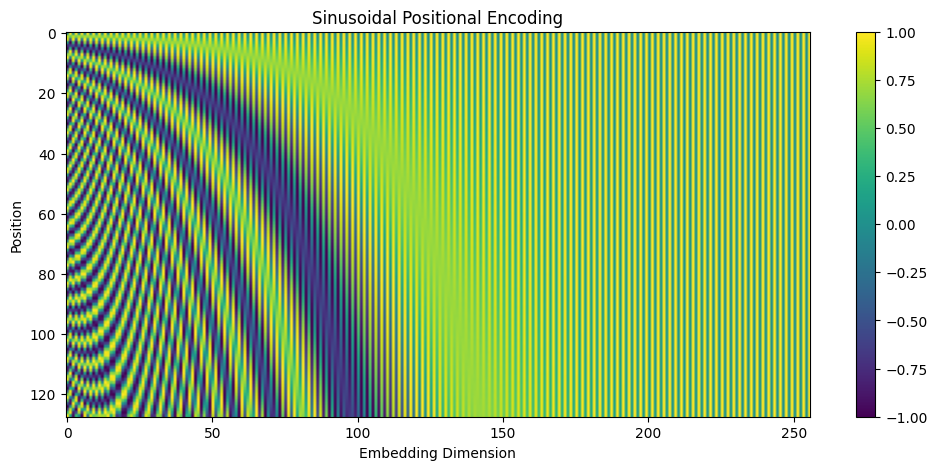

In [19]:
plt.figure(figsize=(12, 5))

plt.imshow(
    pos_encoding.pe[0].cpu().numpy(),
    aspect="auto"
)

plt.xlabel("Embedding Dimension")
plt.ylabel("Position")
plt.title("Sinusoidal Positional Encoding")

plt.colorbar()
plt.show()

### Create one combined embedding module

In [20]:
# ============================================
# Token + Positional Embeddings
# ============================================

class TransformerEmbedding(nn.Module):

    def __init__(self, vocab_size, d_model, max_len):
        super().__init__()

        self.token_embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        self.position_encoding = PositionalEncoding(
            d_model,
            max_len
        )

    def forward(self, x):

        # Token embeddings
        x = self.token_embedding(x)

        # Add positional information
        x = self.position_encoding(x)

        return x

In [21]:
embedding = TransformerEmbedding(
    vocab_size=vocab_size,
    d_model=d_model,
    max_len=block_size
)

embedding = embedding.to(device)

In [22]:
xb, yb = get_batch("train")

x = embedding(xb)

print("Input shape :", xb.shape)
print("Output shape:", x.shape)

Input shape : torch.Size([32, 128])
Output shape: torch.Size([32, 128, 256])


    Token ID
      │
      ▼
    Embedding Matrix
      │
      ▼
    Token Vector
      │
      │  + Positional Encoding
      ▼
    Transformer Input

## Step 3 — Multi-Head Self-Attention

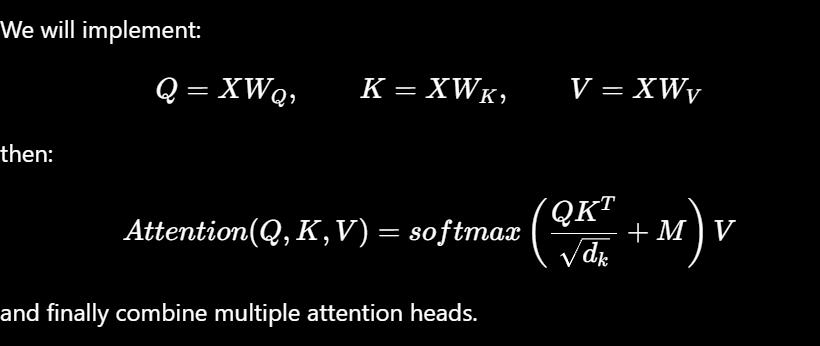

### Set attention hyperparameters

In [23]:
# ============================================
# STEP 3: MULTI-HEAD SELF-ATTENTION
# ============================================

num_heads = 4

assert d_model % num_heads == 0

head_dim = d_model // num_heads

print("Model dimension :", d_model)
print("Number of heads :", num_heads)
print("Head dimension  :", head_dim)

Model dimension : 256
Number of heads : 4
Head dimension  : 64


### The Q, K and V projections

Given:

$$ X\in\mathbb{R}^{B\times T\times d_{model}} $$

we create three learned transformations:

$$ Q=XW_Q $$ $$ K=XW_K $$ $$ V=XW_V $$

where:

$$W_Q, W_K,W_V∈R^{d_{model}×d_{model}}$$
	​


In [27]:
# ============================================
# Q, K, V Projection Layers
# ============================================

W_q = nn.Linear(d_model, d_model, bias=False).to(device)
W_k = nn.Linear(d_model, d_model, bias=False).to(device)
W_v = nn.Linear(d_model, d_model, bias=False).to(device)

print("W_q:", W_q.weight.shape)
print("W_k:", W_k.weight.shape)
print("W_v:", W_v.weight.shape)

W_q: torch.Size([256, 256])
W_k: torch.Size([256, 256])
W_v: torch.Size([256, 256])


### Generate Q, K and V

In [28]:
xb, yb = get_batch("train")

x = embedding(xb)

print("X shape:", x.shape)

X shape: torch.Size([32, 128, 256])


In [29]:
Q = W_q(x)
K = W_k(x)
V = W_v(x)

print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

Q shape: torch.Size([32, 128, 256])
K shape: torch.Size([32, 128, 256])
V shape: torch.Size([32, 128, 256])


### Split into multiple heads

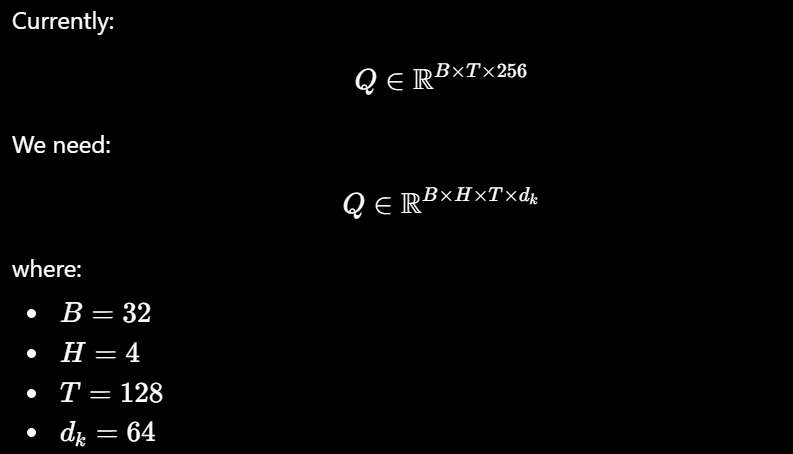

In [30]:
# ============================================
# Split into attention heads
# ============================================

B, T, C = Q.shape

Q = Q.view(B, T, num_heads, head_dim)
K = K.view(B, T, num_heads, head_dim)
V = V.view(B, T, num_heads, head_dim)

# Move head dimension before sequence dimension
Q = Q.transpose(1, 2)
K = K.transpose(1, 2)
V = V.transpose(1, 2)

print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

Q shape: torch.Size([32, 4, 128, 64])
K shape: torch.Size([32, 4, 128, 64])
V shape: torch.Size([32, 4, 128, 64])


### Calculate attention scores

The first major equation is:

$$ Scores = QK^T $$

For every query token, we calculate its similarity with every key token.

In [31]:
scores = Q @ K.transpose(-2, -1)

print("Attention score shape:", scores.shape)

Attention score shape: torch.Size([32, 4, 128, 128])


                Key tokens
              1   2   3   4   5
          ┌────────────────────
    Query 1│
          2│       Attention
          3│        Matrix
          4│
          5│
          └────────────────────

### Scale the attention scores

Large dot products can make softmax unstable.

Therefore:

$$Scores = \frac{QK^T}{\sqrt{d_k}}$$
	​

In [32]:
scores = scores / math.sqrt(head_dim)

print("Scaled attention scores:", scores.shape)

Scaled attention scores: torch.Size([32, 4, 128, 128])


### Causal masking

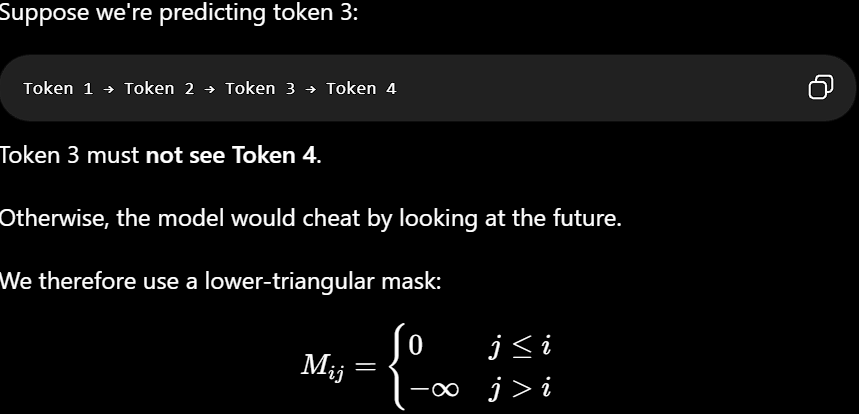

In [33]:
# ============================================
# Causal Mask
# ============================================

mask = torch.tril(
    torch.ones(T, T, device=device)
)

print(mask[:8, :8])

tensor([[1., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1.]], device='cuda:0')


In [34]:
scores = scores.masked_fill(
    mask == 0,
    float("-inf")
)

### Apply softmax

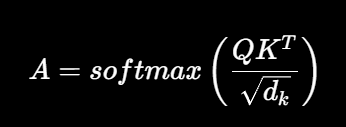

In [35]:
attention_weights = F.softmax(
    scores,
    dim=-1
)

print("Attention weights shape:",
      attention_weights.shape)

Attention weights shape: torch.Size([32, 4, 128, 128])


In [36]:
row_sums = attention_weights[0, 0].sum(dim=-1)

print(row_sums[:10])

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000], device='cuda:0', grad_fn=<SliceBackward0>)


### Multiply by V

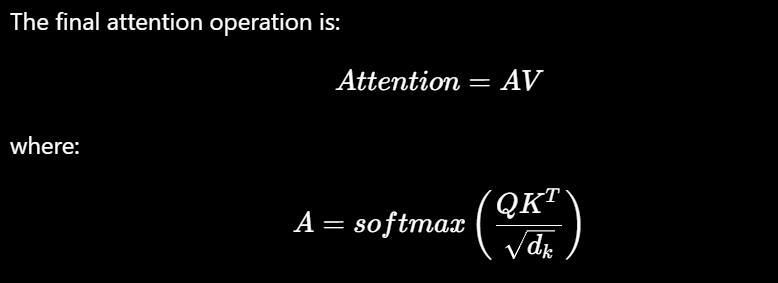

In [37]:
head_output = attention_weights @ V

print("Head output shape:", head_output.shape)

Head output shape: torch.Size([32, 4, 128, 64])


### Combine the attention heads

In [38]:
head_output = head_output.transpose(1, 2)

print(head_output.shape)

torch.Size([32, 128, 4, 64])


In [39]:
# Reshape
head_output = head_output.contiguous().view(
    B, T, d_model
)

print("Combined output shape:", head_output.shape)

Combined output shape: torch.Size([32, 128, 256])


### Output projection

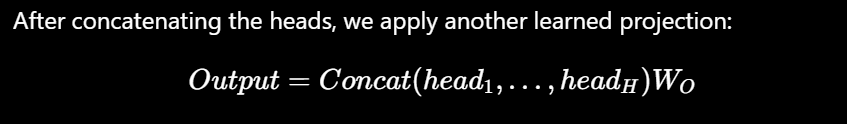

In [41]:
W_o = nn.Linear(
    d_model,
    d_model,
    bias=False
).to(device)

output = W_o(head_output)

print("Final attention output:", output.shape)

Final attention output: torch.Size([32, 128, 256])


### Put everything into one class

In [42]:
# ============================================
# Multi-Head Self-Attention
# ============================================

class MultiHeadSelfAttention(nn.Module):

    def __init__(
        self,
        d_model,
        num_heads,
        max_len
    ):
        super().__init__()

        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        # Q, K, V projections
        self.q_proj = nn.Linear(
            d_model,
            d_model,
            bias=False
        )

        self.k_proj = nn.Linear(
            d_model,
            d_model,
            bias=False
        )

        self.v_proj = nn.Linear(
            d_model,
            d_model,
            bias=False
        )

        # Output projection
        self.out_proj = nn.Linear(
            d_model,
            d_model,
            bias=False
        )

        # Causal mask
        mask = torch.tril(
            torch.ones(max_len, max_len)
        )

        self.register_buffer(
            "mask",
            mask
        )

    def forward(self, x):

        B, T, C = x.shape

        # -------------------------
        # 1. Q, K, V
        # -------------------------

        Q = self.q_proj(x)
        K = self.k_proj(x)
        V = self.v_proj(x)

        # -------------------------
        # 2. Split into heads
        # -------------------------

        Q = Q.view(
            B, T,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)

        K = K.view(
            B, T,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)

        V = V.view(
            B, T,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)

        # -------------------------
        # 3. Attention scores
        # -------------------------

        scores = Q @ K.transpose(-2, -1)

        scores = scores / math.sqrt(
            self.head_dim
        )

        # -------------------------
        # 4. Causal mask
        # -------------------------

        scores = scores.masked_fill(
            self.mask[:T, :T] == 0,
            float("-inf")
        )

        # -------------------------
        # 5. Softmax
        # -------------------------

        attention_weights = F.softmax(
            scores,
            dim=-1
        )

        # -------------------------
        # 6. Weighted values
        # -------------------------

        out = attention_weights @ V

        # -------------------------
        # 7. Combine heads
        # -------------------------

        out = out.transpose(1, 2).contiguous()

        out = out.view(
            B, T, self.d_model
        )

        # -------------------------
        # 8. Output projection
        # -------------------------

        out = self.out_proj(out)

        return out

### Test our attention module

In [48]:
attention = MultiHeadSelfAttention(
    d_model=d_model,
    num_heads=num_heads,
    max_len=block_size
).to(device)

In [45]:
xb, yb = get_batch("train")

x = embedding(xb)

attention_output = attention(x)

print("Input shape :", x.shape)
print("Output shape:", attention_output.shape)

Input shape : torch.Size([32, 128, 256])
Output shape: torch.Size([32, 128, 256])


### Visualize an attention matrix

In [46]:
# ============================================
# Multi-Head Self-Attention
# ============================================

class MultiHeadSelfAttention(nn.Module):

    def __init__(
        self,
        d_model,
        num_heads,
        max_len
    ):
        super().__init__()

        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        # Q, K, V projections
        self.q_proj = nn.Linear(
            d_model,
            d_model,
            bias=False
        )

        self.k_proj = nn.Linear(
            d_model,
            d_model,
            bias=False
        )

        self.v_proj = nn.Linear(
            d_model,
            d_model,
            bias=False
        )

        # Output projection
        self.out_proj = nn.Linear(
            d_model,
            d_model,
            bias=False
        )

        # Causal mask
        mask = torch.tril(
            torch.ones(max_len, max_len)
        )

        self.register_buffer(
            "mask",
            mask
        )

    def forward(self, x):

        B, T, C = x.shape

        # -------------------------
        # 1. Q, K, V
        # -------------------------

        Q = self.q_proj(x)
        K = self.k_proj(x)
        V = self.v_proj(x)

        # -------------------------
        # 2. Split into heads
        # -------------------------

        Q = Q.view(
            B, T,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)

        K = K.view(
            B, T,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)

        V = V.view(
            B, T,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)

        # -------------------------
        # 3. Attention scores
        # -------------------------

        scores = Q @ K.transpose(-2, -1)

        scores = scores / math.sqrt(
            self.head_dim
        )

        # -------------------------
        # 4. Causal mask
        # -------------------------

        scores = scores.masked_fill(
            self.mask[:T, :T] == 0,
            float("-inf")
        )

        # -------------------------
        # 5. Softmax
        # -------------------------

        attention_weights = F.softmax(
            scores,
            dim=-1
        )

        # -------------------------
        # 6. Weighted values
        # -------------------------

        out = attention_weights @ V

        # -------------------------
        # 7. Combine heads
        # -------------------------

        out = out.transpose(1, 2).contiguous()

        out = out.view(
            B, T, self.d_model
        )

        # -------------------------
        # 8. Output projection
        # -------------------------

        out = self.out_proj(out)

        return out, attention_weights

In [50]:
attention_output, attention_weights = attention(x)

print("Output:", attention_output.shape)
print("Attention:", attention_weights.shape)

Output: torch.Size([32, 128, 256])
Attention: torch.Size([32, 4, 128, 128])


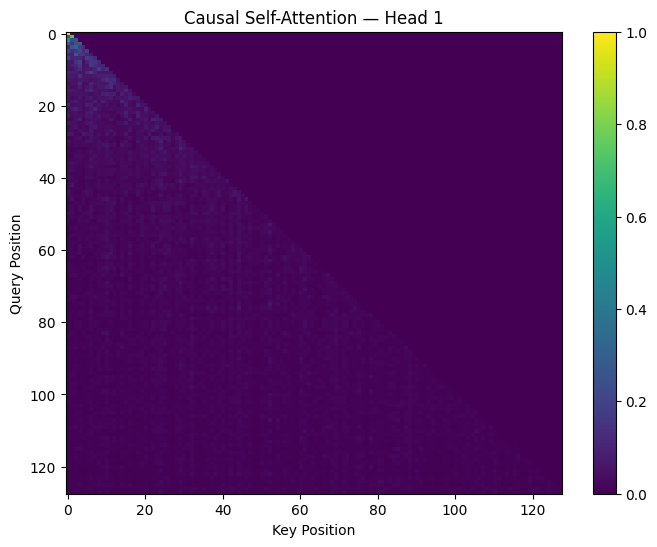

In [51]:
plt.figure(figsize=(8, 6))

plt.imshow(
    attention_weights[0, 0].detach().cpu().numpy(),
    aspect="auto"
)

plt.xlabel("Key Position")
plt.ylabel("Query Position")
plt.title("Causal Self-Attention — Head 1")

plt.colorbar()
plt.show()

                  X
                  │
          ┌────────┼────────┐
          ↓        ↓        ↓
        Q         K        V
          │        │        │
          └───┬────┘        │
              ↓             │
            QKᵀ             │
              ↓             │
        Divide √dₖ          │
              ↓             │
        Causal Mask         │
              ↓             │
            Softmax         │
              ↓             │
              A─────────────┘
              │
              ↓
            AV
              │
              ↓
        Concatenate Heads
              │
              ↓
        Output Projection
              │
              ↓
            Output

## Step 4 — Feed-Forward Network + LayerNorm + Residual Connections

    Input X
      │
      ▼
    Multi-Head Self-Attention
      │
      ▼
    Add + LayerNorm
      │
      ▼
    Feed-Forward Network
      │
      ▼
    Add + LayerNorm
      │
      ▼
    Output

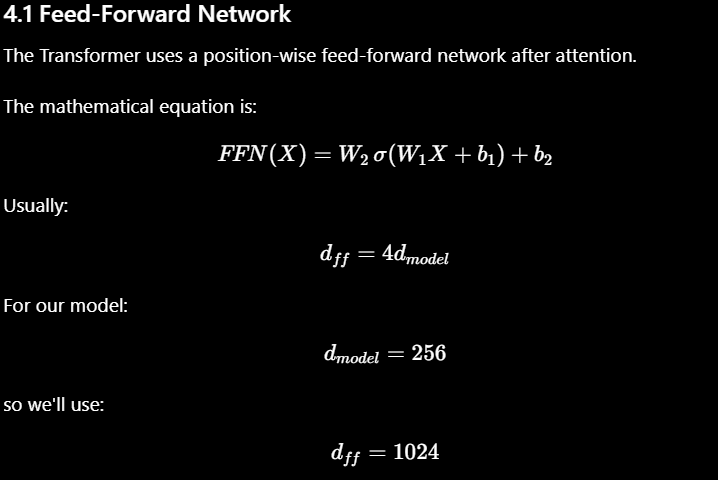

    256
    ↓
    Linear
    ↓
    1024
    ↓
    GELU
    ↓
    Dropout
    ↓
    Linear
    ↓
    256

In [52]:
# ============================================
# STEP 4: FEED-FORWARD NETWORK
# ============================================

d_ff = 4 * d_model
dropout = 0.1

print("d_model :", d_model)
print("d_ff    :", d_ff)
print("dropout :", dropout)

d_model : 256
d_ff    : 1024
dropout : 0.1


### Implement the Feed-Forward Network

In [53]:
class FeedForward(nn.Module):

    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.network(x)

In [54]:
ffn = FeedForward(
    d_model=d_model,
    d_ff=d_ff,
    dropout=dropout
).to(device)

### Test the FFN

In [55]:
xb, yb = get_batch("train")

x = embedding(xb)

attention_output, attention_weights = attention(x)

ffn_output = ffn(attention_output)

print("Input to FFN :", attention_output.shape)
print("Output from FFN:", ffn_output.shape)

Input to FFN : torch.Size([32, 128, 256])
Output from FFN: torch.Size([32, 128, 256])


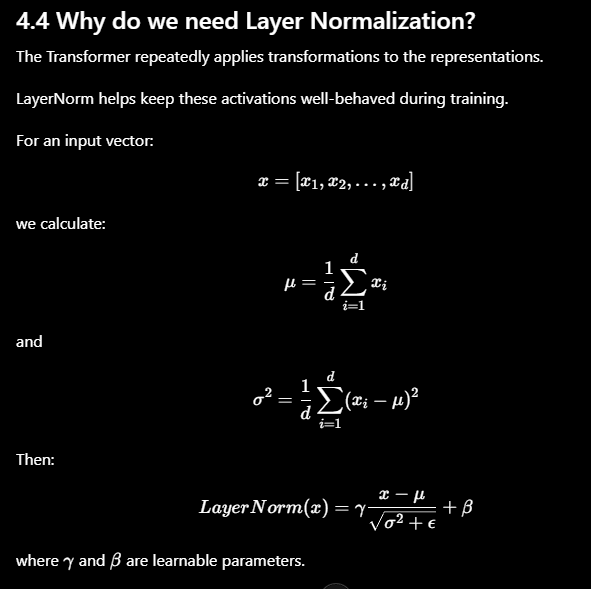

In [56]:
layer_norm = nn.LayerNorm(d_model)

### Residual Connections

This is another critical Transformer component.

Instead of:

$$ X\rightarrow Attention(X) $$

we use:

$$ X+Attention(X) $$

This is called a residual/skip connection.

The same idea is used around the FFN:

$$X+FFN(X)$$

                ┌───────────────┐
                │               │
                ↓               │
    X → Attention → Add → LayerNorm
                      ↑
                      │
                      └──────── X

### Build the complete Transformer Block

Now we combine:

Multi-head self-attention
Residual connection
LayerNorm
Feed-forward network
Another residual connection
Another LayerNorm
Dropout

We'll use the Pre-LayerNorm architecture because it is easier to train for our small model.

The equations are:

$$ X_1=X+Attention(LN(X)) $$
$$X_2 = X_1+FFN(LN(X_1))$$

                ┌──────────────────────────────┐
                │                              │
                │                              ▼
    X ──────────► LayerNorm ──► Attention ──► Add
    │                                             │
    │                                             ▼
    │                                            X₁
    │                                             │
    │             ┌──────────────────────────────┤
    │             │                              │
    │             │                              ▼
    └─────────────┘                         LayerNorm
                                                │
                                                ▼
                                                FFN
                                                │
                                                ▼
                                                Add
                                                │
                                                ▼
                                                X₂

### Implement TransformerBlock

In [57]:
# ============================================
# Transformer Block
# ============================================

class TransformerBlock(nn.Module):

    def __init__(
        self,
        d_model,
        num_heads,
        d_ff,
        max_len,
        dropout=0.1
    ):
        super().__init__()

        # Layer Normalization
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

        # Multi-head self-attention
        self.attention = MultiHeadSelfAttention(
            d_model=d_model,
            num_heads=num_heads,
            max_len=max_len
        )

        # Feed-forward network
        self.ffn = FeedForward(
            d_model=d_model,
            d_ff=d_ff,
            dropout=dropout
        )

        # Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        # --------------------------------
        # Attention sub-layer
        # --------------------------------

        normalized_x = self.ln1(x)

        attention_output, attention_weights = \
            self.attention(normalized_x)

        x = x + self.dropout(attention_output)

        # --------------------------------
        # Feed-forward sub-layer
        # --------------------------------

        normalized_x = self.ln2(x)

        ffn_output = self.ffn(normalized_x)

        x = x + ffn_output

        return x, attention_weights

### Test the Transformer Block

In [58]:
block = TransformerBlock(
    d_model=d_model,
    num_heads=num_heads,
    d_ff=d_ff,
    max_len=block_size,
    dropout=dropout
).to(device)

In [59]:
xb, yb = get_batch("train")

x = embedding(xb)

output, attention_weights = block(x)

print("Input shape :", x.shape)
print("Output shape:", output.shape)
print("Attention shape:", attention_weights.shape)

Input shape : torch.Size([32, 128, 256])
Output shape: torch.Size([32, 128, 256])
Attention shape: torch.Size([32, 4, 128, 128])


### Count the parameters

In [60]:
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

print(
    "Transformer block parameters:",
    count_parameters(block)
)

Transformer block parameters: 788736


### Stack multiple Transformer blocks

In [61]:
num_layers = 4

print("Number of Transformer blocks:", num_layers)

Number of Transformer blocks: 4


In [62]:
transformer_blocks = nn.ModuleList([
    TransformerBlock(
        d_model=d_model,
        num_heads=num_heads,
        d_ff=d_ff,
        max_len=block_size,
        dropout=dropout
    )
    for _ in range(num_layers)
]).to(device)

print("Number of blocks:", len(transformer_blocks))

Number of blocks: 4


### Pass data through all blocks

In [63]:
xb, yb = get_batch("train")

x = embedding(xb)

all_attention_weights = []

for block in transformer_blocks:

    x, attention_weights = block(x)

    all_attention_weights.append(
        attention_weights
    )

print("Final output shape:", x.shape)
print(
    "Number of attention maps:",
    len(all_attention_weights)
)

Final output shape: torch.Size([32, 128, 256])
Number of attention maps: 4


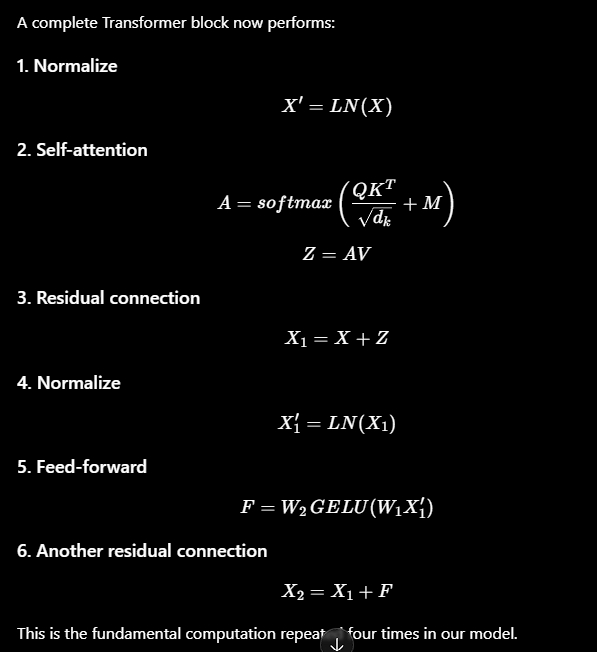

    Token IDs
        ↓
    Token Embedding
        ↓
    Positional Encoding
        ↓
    Transformer Block 1
        ↓
    Transformer Block 2
        ↓
    Transformer Block 3
        ↓
    Transformer Block 4
        ↓
    Final representation

                  TRANSFORMER
                      │
          ┌───────────┴───────────┐
          │                       │
    Embeddings              Transformer Blocks
          │                       │
          │              ┌────────┴────────┐
          │              │                 │
          │          Attention            FFN
          │              │                 │
          │          Add + LN          Add + LN
          │              │                 │
          │              └────────┬────────┘
          │                       │
          └───────────────► Final Representation

## Step 5 — Build the Complete Transformer Language Model

      Token IDs
          ↓
      Token Embedding
          +
      Positional Encoding
          ↓
      Transformer Block × 4
          │
          ├── LayerNorm
          ├── Masked Multi-Head Self-Attention
          ├── Residual Connection
          ├── LayerNorm
          ├── Feed-Forward Network
          └── Residual Connection
          ↓
      Final LayerNorm
          ↓
      Linear Language Model Head
          ↓
      Logits
          ↓
      Softmax
          ↓
      Next-Token Probabilities

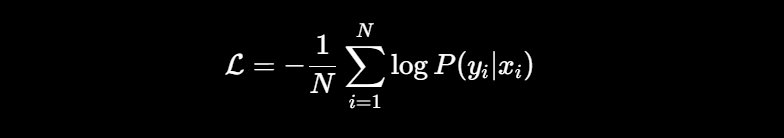

In [64]:
# ============================================
# STEP 5: COMPLETE TRANSFORMER LANGUAGE MODEL
# ============================================

print("Vocabulary size :", vocab_size)
print("Block size      :", block_size)
print("d_model         :", d_model)
print("num_heads       :", num_heads)
print("head_dim        :", head_dim)
print("d_ff            :", d_ff)
print("num_layers      :", num_layers)
print("dropout         :", dropout)
print("device          :", device)

Vocabulary size : 65
Block size      : 128
d_model         : 256
num_heads       : 4
head_dim        : 64
d_ff            : 1024
num_layers      : 4
dropout         : 0.1
device          : cuda


### Build the complete Transformer

In [65]:
class TransformerLanguageModel(nn.Module):

    def __init__(
        self,
        vocab_size,
        d_model,
        num_heads,
        d_ff,
        num_layers,
        max_len,
        dropout=0.1
    ):
        super().__init__()

        # --------------------------------
        # Token + positional embeddings
        # --------------------------------

        self.embedding = TransformerEmbedding(
            vocab_size=vocab_size,
            d_model=d_model,
            max_len=max_len
        )

        # --------------------------------
        # Transformer blocks
        # --------------------------------

        self.blocks = nn.ModuleList([
            TransformerBlock(
                d_model=d_model,
                num_heads=num_heads,
                d_ff=d_ff,
                max_len=max_len,
                dropout=dropout
            )
            for _ in range(num_layers)
        ])

        # --------------------------------
        # Final LayerNorm
        # --------------------------------

        self.ln_f = nn.LayerNorm(d_model)

        # --------------------------------
        # Language Model Head
        # --------------------------------

        self.lm_head = nn.Linear(
            d_model,
            vocab_size
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, idx, targets=None):

        # --------------------------------
        # 1. Embeddings
        # --------------------------------

        x = self.embedding(idx)

        x = self.dropout(x)

        # Store attention maps
        attention_maps = []

        # --------------------------------
        # 2. Transformer blocks
        # --------------------------------

        for block in self.blocks:

            x, attention_weights = block(x)

            attention_maps.append(
                attention_weights
            )

        # --------------------------------
        # 3. Final normalization
        # --------------------------------

        x = self.ln_f(x)

        # --------------------------------
        # 4. Language model head
        # --------------------------------

        logits = self.lm_head(x)

        loss = None

        # --------------------------------
        # 5. Calculate loss
        # --------------------------------

        if targets is not None:

            B, T, C = logits.shape

            logits_flat = logits.view(
                B * T,
                C
            )

            targets_flat = targets.view(
                B * T
            )

            loss = F.cross_entropy(
                logits_flat,
                targets_flat
            )

        return logits, loss, attention_maps

### Create our model

In [66]:
model = TransformerLanguageModel(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=num_heads,
    d_ff=d_ff,
    num_layers=num_layers,
    max_len=block_size,
    dropout=dropout
).to(device)

print(model)

TransformerLanguageModel(
  (embedding): TransformerEmbedding(
    (token_embedding): Embedding(65, 256)
    (position_encoding): PositionalEncoding()
  )
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attention): MultiHeadSelfAttention(
        (q_proj): Linear(in_features=256, out_features=256, bias=False)
        (k_proj): Linear(in_features=256, out_features=256, bias=False)
        (v_proj): Linear(in_features=256, out_features=256, bias=False)
        (out_proj): Linear(in_features=256, out_features=256, bias=False)
      )
      (ffn): FeedForward(
        (network): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=1024, out_features=256, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
      )
      (dropout)

### Count the model parameters

In [67]:
total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total trainable parameters: "
    f"{total_params:,}"
)

Total trainable parameters: 3,188,801


### Test the complete forward pass

In [68]:
xb, yb = get_batch("train")

logits, loss, attention_maps = model(
    xb,
    yb
)

print("Input shape       :", xb.shape)
print("Logits shape      :", logits.shape)
print("Loss              :", loss.item())
print("Attention layers  :", len(attention_maps))
print("Attention shape   :", attention_maps[0].shape)

Input shape       : torch.Size([32, 128])
Logits shape      : torch.Size([32, 128, 65])
Loss              : 4.3651204109191895
Attention layers  : 4
Attention shape   : torch.Size([32, 4, 128, 128])


Why is the logits shape:
$$ [32,128,65] $$

?

Because for every position, the model predicts a probability distribution over the entire vocabulary.

Therefore:

$$ B\times T\times V $$
=32×128×65

### Understand logits

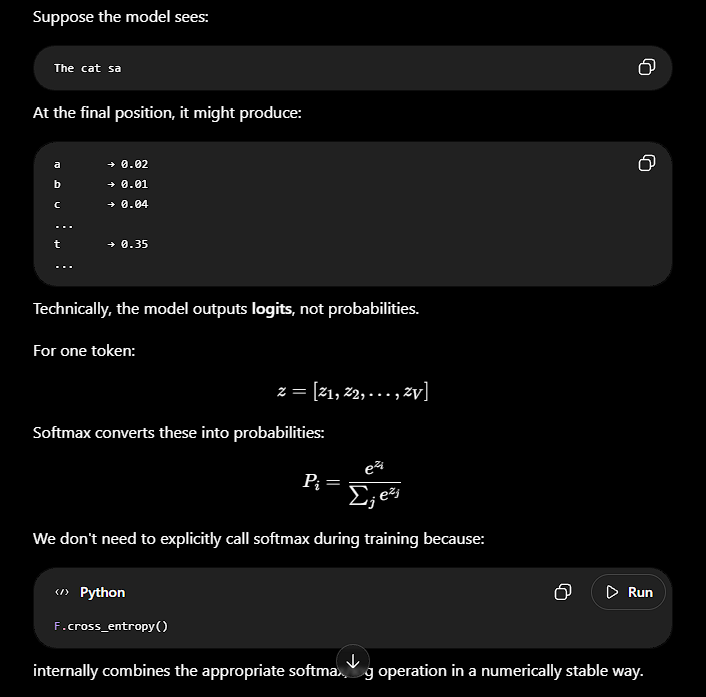

### Check the initial loss

In [70]:
print("Initial loss:", loss.item())

Initial loss: 4.3651204109191895


### Verify causal masking

In [71]:
attn = attention_maps[0]

print("Attention shape:", attn.shape)

print("\nFirst 8 × 8 attention values:")
print(
    attn[0, 0, :8, :8].detach().cpu()
)

Attention shape: torch.Size([32, 4, 128, 128])

First 8 × 8 attention values:
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4951, 0.5049, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3023, 0.3265, 0.3713, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2378, 0.1896, 0.2967, 0.2759, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1824, 0.3114, 0.1809, 0.1496, 0.1757, 0.0000, 0.0000, 0.0000],
        [0.0717, 0.0834, 0.1943, 0.2648, 0.1985, 0.1873, 0.0000, 0.0000],
        [0.1638, 0.1806, 0.1524, 0.1775, 0.1072, 0.0989, 0.1196, 0.0000],
        [0.1375, 0.0920, 0.1027, 0.1625, 0.1696, 0.0837, 0.1258, 0.1262]])


### Generate text before training

We can already make the model generate text, although it will be random nonsense because it hasn't learned yet.

In [72]:
@torch.no_grad()
def generate(
    model,
    idx,
    max_new_tokens,
    temperature=1.0
):

    model.eval()

    for _ in range(max_new_tokens):

        # Keep only the last block_size tokens
        idx_cond = idx[:, -block_size:]

        # Forward pass
        logits, _, _ = model(idx_cond)

        # Take logits from final position
        logits = logits[:, -1, :]

        # Temperature scaling
        logits = logits / temperature

        # Convert to probabilities
        probs = F.softmax(
            logits,
            dim=-1
        )

        # Sample next token
        next_token = torch.multinomial(
            probs,
            num_samples=1
        )

        # Append token
        idx = torch.cat(
            (idx, next_token),
            dim=1
        )

    model.train()

    return idx

### Test text generation

In [73]:
prompt = "ROMEO:"

In [74]:
context = torch.tensor(
    [encode(prompt)],
    dtype=torch.long,
    device=device
)

generated = generate(
    model,
    context,
    max_new_tokens=200,
    temperature=1.0
)

generated_text = decode(
    generated[0].tolist()
)

print(generated_text)

ROMEO:?tlwkztWMggZd!:jJYkzs-i3EB:z'eJEVa!pXyC,gMb;PMz&&JJ$GFmgIoImFG:KLOYyIrZLRfG!IinixfBKRPWdIIixCBNQ'i'Y-OVv:HBOyvqPdyR 
iGWpyJUckK,sJxk,tf'Nh:t: !dNGKUJPlHyxLxVsjJXgp?H:f'vX;agCfi.IEjsKys:cdKzP'SHxNSZjYy


### Calculate perplexity

For language models, another important metric is perplexity.

The relationship is:

$$ PPL=e^{\mathcal L} $$

where $\mathcal L$ is the average cross-entropy loss.

In [75]:
def perplexity(loss):
    return math.exp(loss)

In [76]:
current_loss = loss.item()

print("Loss       :", current_loss)
print("Perplexity :", perplexity(current_loss))

Loss       : 4.3651204109191895
Perplexity : 78.65887075850104


### Create a model summary

In [77]:
print("=" * 50)
print("TRANSFORMER LANGUAGE MODEL")
print("=" * 50)

print(f"Vocabulary size      : {vocab_size}")
print(f"Context length       : {block_size}")
print(f"Embedding dimension  : {d_model}")
print(f"Attention heads       : {num_heads}")
print(f"Head dimension        : {head_dim}")
print(f"FFN dimension         : {d_ff}")
print(f"Transformer layers    : {num_layers}")
print(f"Dropout               : {dropout}")
print(f"Parameters            : {total_params:,}")
print("=" * 50)

TRANSFORMER LANGUAGE MODEL
Vocabulary size      : 65
Context length       : 128
Embedding dimension  : 256
Attention heads       : 4
Head dimension        : 64
FFN dimension         : 1024
Transformer layers    : 4
Dropout               : 0.1
Parameters            : 3,188,801


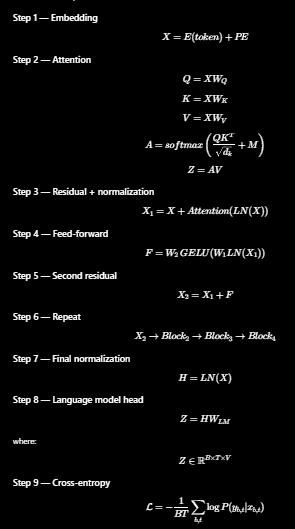

                            TRANSFORMER LM
                                  │
                ┌────────────────┴────────────────┐
                │                                 │
          Token Embedding                  Positional Encoding
                │                                 │
                └───────────────┬─────────────────┘
                                ↓
                        Transformer Block 1
                                ↓
                        Transformer Block 2
                                ↓
                        Transformer Block 3
                                ↓
                        Transformer Block 4
                                ↓
                          Final LayerNorm
                                ↓
                            LM Head
                                ↓
                              Logits
                                ↓
                        Cross-Entropy Loss

## Step 6 — Train the Transformer

      Training Data
          ↓
      Random Batches
          ↓
      Transformer
          ↓
      Logits
          ↓
      Cross-Entropy Loss
          ↓
      Backpropagation
          ↓
      AdamW
          ↓
      Update Parameters
          ↓
      Repeat

In [78]:
# ============================================
# STEP 6: TRAINING
# ============================================

learning_rate = 3e-4
max_iters = 5000

eval_interval = 500
eval_iters = 100

batch_size = 32

print("Learning rate :", learning_rate)
print("Max iterations:", max_iters)
print("Batch size    :", batch_size)
print("Eval interval :", eval_interval)

Learning rate : 0.0003
Max iterations: 5000
Batch size    : 32
Eval interval : 500


In [79]:
# ============================================
# Optimizer
# ============================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=0.01
)

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    weight_decay: 0.01
)


In [80]:
# ============================================
# Evaluation function
# ============================================

@torch.no_grad()
def estimate_loss():

    model.eval()

    losses = {}

    for split in ["train", "val"]:

        loss_values = []

        for _ in range(eval_iters):

            X, Y = get_batch(split)

            _, loss, _ = model(X, Y)

            loss_values.append(
                loss.item()
            )

        losses[split] = sum(loss_values) / len(loss_values)

    model.train()

    return losses

### Test the evaluation function

In [81]:
losses = estimate_loss()

print("Initial training loss   :", losses["train"])
print("Initial validation loss :", losses["val"])

print("Initial training PPL    :", math.exp(losses["train"]))
print("Initial validation PPL  :", math.exp(losses["val"]))

Initial training loss   : 4.361122207641602
Initial validation loss : 4.35584635257721
Initial training PPL    : 78.34500447234247
Initial validation PPL  : 77.9327560214979


### Training loop

In [82]:
# ============================================
# Training Loop
# ============================================

train_losses = []
val_losses = []

for iteration in range(max_iters):

    # -----------------------------
    # Evaluate periodically
    # -----------------------------

    if iteration % eval_interval == 0:

        losses = estimate_loss()

        train_loss = losses["train"]
        val_loss = losses["val"]

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"Step {iteration:5d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train PPL: {math.exp(train_loss):.2f} | "
            f"Val PPL: {math.exp(val_loss):.2f}"
        )

    # -----------------------------
    # Get training batch
    # -----------------------------

    X, Y = get_batch("train")

    # -----------------------------
    # Forward pass
    # -----------------------------

    logits, loss, _ = model(X, Y)

    # -----------------------------
    # Clear old gradients
    # -----------------------------

    optimizer.zero_grad(set_to_none=True)

    # -----------------------------
    # Backpropagation
    # -----------------------------

    loss.backward()

    # -----------------------------
    # Update parameters
    # -----------------------------

    optimizer.step()

Step     0 | Train Loss: 4.3610 | Val Loss: 4.3549 | Train PPL: 78.33 | Val PPL: 77.86
Step   500 | Train Loss: 2.0148 | Val Loss: 2.0819 | Train PPL: 7.50 | Val PPL: 8.02
Step  1000 | Train Loss: 1.7410 | Val Loss: 1.8920 | Train PPL: 5.70 | Val PPL: 6.63
Step  1500 | Train Loss: 1.5931 | Val Loss: 1.7705 | Train PPL: 4.92 | Val PPL: 5.87
Step  2000 | Train Loss: 1.5091 | Val Loss: 1.7066 | Train PPL: 4.52 | Val PPL: 5.51
Step  2500 | Train Loss: 1.4537 | Val Loss: 1.6638 | Train PPL: 4.28 | Val PPL: 5.28
Step  3000 | Train Loss: 1.4090 | Val Loss: 1.6186 | Train PPL: 4.09 | Val PPL: 5.05
Step  3500 | Train Loss: 1.3817 | Val Loss: 1.5958 | Train PPL: 3.98 | Val PPL: 4.93
Step  4000 | Train Loss: 1.3487 | Val Loss: 1.5658 | Train PPL: 3.85 | Val PPL: 4.79
Step  4500 | Train Loss: 1.3234 | Val Loss: 1.5594 | Train PPL: 3.76 | Val PPL: 4.76


### Plot the training curves

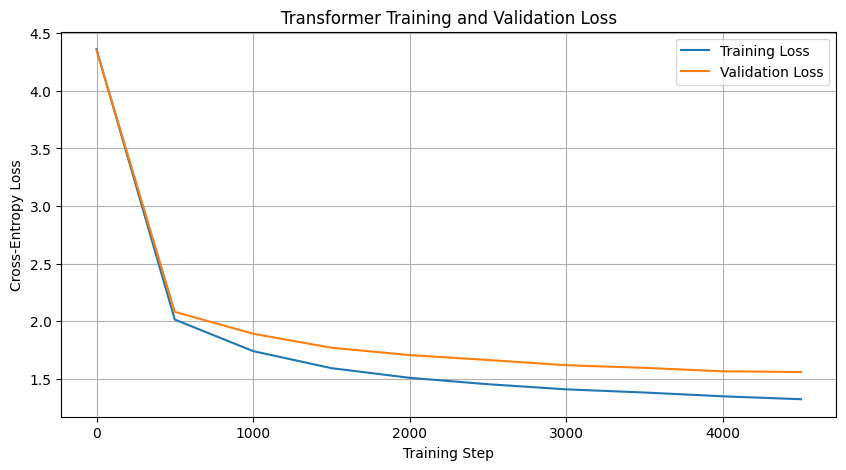

In [83]:
# ============================================
# Training Curves
# ============================================

steps = list(
    range(
        0,
        max_iters,
        eval_interval
    )
)

# Make sure lengths match
steps = steps[:len(train_losses)]

plt.figure(figsize=(10, 5))

plt.plot(
    steps,
    train_losses,
    label="Training Loss"
)

plt.plot(
    steps,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Training Step")
plt.ylabel("Cross-Entropy Loss")
plt.title("Transformer Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

### Calculate final perplexity

In [84]:
final_losses = estimate_loss()

final_train_loss = final_losses["train"]
final_val_loss = final_losses["val"]

train_ppl = math.exp(final_train_loss)
val_ppl = math.exp(final_val_loss)

print("========================================")
print("FINAL RESULTS")
print("========================================")

print(f"Training Loss      : {final_train_loss:.4f}")
print(f"Validation Loss    : {final_val_loss:.4f}")

print(f"Training Perplexity: {train_ppl:.2f}")
print(f"Validation PPL     : {val_ppl:.2f}")

FINAL RESULTS
Training Loss      : 1.3024
Validation Loss    : 1.5448
Training Perplexity: 3.68
Validation PPL     : 4.69


### Generate text from the trained model

In [85]:
# ============================================
# Text Generation
# ============================================

prompt = "ROMEO:"

context = torch.tensor(
    [encode(prompt)],
    dtype=torch.long,
    device=device
)

generated = generate(
    model,
    context,
    max_new_tokens=500,
    temperature=0.8
)

generated_text = decode(
    generated[0].tolist()
)

print(generated_text)

ROMEO:
Then! What then? say's the should not shows
That behold into your life, against Marcius,
That the Volsces of the untearneats,
Or enemies to the armourned and to his choice:
Besides treason of the prival tears good to want,
And the begar the banishment, she was she with his.
how cannot my own soul, and send be changed
By and with the speak of a brace of death,
Upon that he better should to much and so much news,
And Hereton man's wife, and us have well from me
As I consent and these can so speak


### Try different temperatures

In [86]:
# Lower temperature
generated = generate(
    model,
    context,
    max_new_tokens=500,
    temperature=0.5
)

print(
    decode(generated[0].tolist())
)

ROMEO:
Now, noble such a first as a secret
To counteraties the grave of the hands
And I will be the duked of the body of the time
That he the of the world of our servant that call
That had been her bear to the friends sound?

DUKE VINCENTIO:
I am so this citizens, good madam,
Thou dost not the bed them the world that we shall
Of the speech of the eyes of the deed,
And not the same of the world of the poil of the world:
And the is a son trust the body with the fair of thee.

DUKE VINCENTIO:
But enemies


In [87]:
# Higher temperature
generated = generate(
    model,
    context,
    max_new_tokens=500,
    temperature=1.2
)

print(
    decode(generated[0].tolist())
)

ROMEO:
Kind up,--

ROMEO:
'Tis death, worthy queen, ever thee, two
ByORK: calque lords beduputcless! That's toouch'd sain;
Metime
The gods of their straits chase; the are officer?
That's a time and his son birn as elded?

CLIFFFORD:
Hold, Clarence,
What! he's left! my heart's and hangly,
Sweet, all they, or comfort-dead; and Edmupter' sake,
Was trute nor me thee of love this?

FRANAR HI
MONT:
I intend he hath mad;
For underscartarhmbers battles call than they
By my cousin's nor unwilborn.

Second Juli


### Save the trained model

In [88]:
# ============================================
# Save Model Checkpoint
# ============================================

checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "vocab_size": vocab_size,
    "d_model": d_model,
    "num_heads": num_heads,
    "d_ff": d_ff,
    "num_layers": num_layers,
    "block_size": block_size,
    "stoi": stoi,
    "itos": itos
}

torch.save(
    checkpoint,
    "transformer_shakespeare.pt"
)

print("Model checkpoint saved!")

Model checkpoint saved!


### Check the checkpoint

In [89]:
import os

file_size = os.path.getsize(
    "transformer_shakespeare.pt"
)

print(
    f"Checkpoint size: "
    f"{file_size / (1024**2):.2f} MB"
)

Checkpoint size: 36.94 MB


### Save the loss data

In [90]:
import json

results = {
    "steps": steps,
    "train_loss": train_losses,
    "val_loss": val_losses,
    "final_train_loss": final_train_loss,
    "final_val_loss": final_val_loss,
    "train_perplexity": train_ppl,
    "val_perplexity": val_ppl
}

with open(
    "training_results.json",
    "w"
) as f:
    json.dump(results, f, indent=4)

print("Training results saved!")

Training results saved!


### Gradient clipping

## Step 7 — Model Analysis & Attention Visualization

### Load the trained model

In [92]:
# ============================================
# STEP 7: MODEL ANALYSIS
# ============================================

checkpoint = torch.load(
    "transformer_shakespeare.pt",
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Trained model loaded successfully!")

Trained model loaded successfully!


### Generate a clean sample

In [93]:
@torch.no_grad()
def generate_text(prompt, max_new_tokens=500, temperature=0.8):

    context = torch.tensor(
        [encode(prompt)],
        dtype=torch.long,
        device=device
    )

    generated = generate(
        model,
        context,
        max_new_tokens=max_new_tokens,
        temperature=temperature
    )

    return decode(
        generated[0].tolist()
    )

In [94]:
sample_text = generate_text(
    "ROMEO:",
    max_new_tokens=500,
    temperature=0.8
)

print(sample_text)

ROMEO:
You doth not seem her in the call not my son,
And I am spare be seen as I could lengthen,
As we hated reply served him we have:
Now me not no more to have presently thee?
But I'll with shade hence his wise son.

TRANIO:
More such a vallour?

PERDITA:
I know, and at say the speaks to death:
O good more be on senses there I saw of thee,
Swear his court by his furied brother war;
Now he seem to speak a man obedience
And then unatural bend to Buckingham,
I'll desire he had revolt, as he did spent h


In [95]:
prompts = [
    "ROMEO:",
    "JULIET:",
    "KING:",
    "To be,"
]

for prompt in prompts:

    print("=" * 70)
    print("PROMPT:", prompt)
    print("=" * 70)

    print(
        generate_text(
            prompt,
            max_new_tokens=300,
            temperature=0.8
        )
    )

PROMPT: ROMEO:
ROMEO:
He shortly words: I do not be his provost;
But 'Tis new be soon purge and traitor,
The common much in the deep of peace, on my hand,
I charge most deed send that then by a men's claim'd
Which heart's sight; and in power thee were tale
Twelcome, must have have the Antiat,
And there his such shall be
PROMPT: JULIET:
JULIET:
This tender you all this firsting in in their battless.

QUEEN ELIZABETH:
Why, in else, my lord?

KING RICHARD II:
He was me his men.

BUCKINGHAM:
Menen, Troy lord:
Away! the newly deny comes to you.

GLOUCESTER:
As I that I meant a son.

CLARENCE:
Come, good madam, are the bold and death love.
Wha
PROMPT: KING:
KING:
Go, my lord, seem the people:
Then will die it be a book and for queen
Makes it makes me to the cause. This blood
Is want the Caper of Frence' is speak; that seems the fortuness
They forget his seeming maids person.

CLAUDIO:
As sett had his blood very brother's mouth
Shall be muchborn'd all of Glo
PROMPT: To be,
To be, think I can 

### Compare different temperatures

In [96]:
prompt = "ROMEO:"

temperatures = [0.5, 0.8, 1.0, 1.2]

for temp in temperatures:

    print("\n")
    print("=" * 70)
    print(f"TEMPERATURE = {temp}")
    print("=" * 70)

    print(
        generate_text(
            prompt,
            max_new_tokens=250,
            temperature=temp
        )
    )



TEMPERATURE = 0.5
ROMEO:
Madam, these is that hast made the new first it.

LEONTES:
I do not thee:
The heavens is the prince I see thee were the world,
And the begar of his grown death.

CLARENCE:
So shall be said 'Angelo to have been
He hath been with the seasons of his li


TEMPERATURE = 0.8
ROMEO:
Why is must be saved my both.

QUEEN ELIZABETH:
When is seven enjoy?

CLARENCE:
Now, by my right is good forbids be man,
And, then weaked by my night soul,
What will I the fearful of your life.

LADY CAPULET:
The queen you and herd with staughter to


TEMPERATURE = 1.0
ROMEO:
Death, the raw matter; and for low!
Of it true and tempty of them; were thy heart
whose shall be sound our grant of a bestraine
tear time to sleep 'love--
Whether nor the Verenal swells demer:
What say Richard?

PAULINA:
Ay, to look be us and thing 


TEMPERATURE = 1.2
ROMEO:
Now palague I wi'll gament, to report.

CLAUDIO:
That we, foul not accused,
Lies to, and may parlica' here to us with him but
And pest so a st

### Analyze training and validation loss

In [97]:
import json

with open(
    "training_results.json",
    "r"
) as f:

    results = json.load(f)

steps = results["steps"]
train_losses = results["train_loss"]
val_losses = results["val_loss"]

print("Training points:", len(train_losses))

Training points: 10


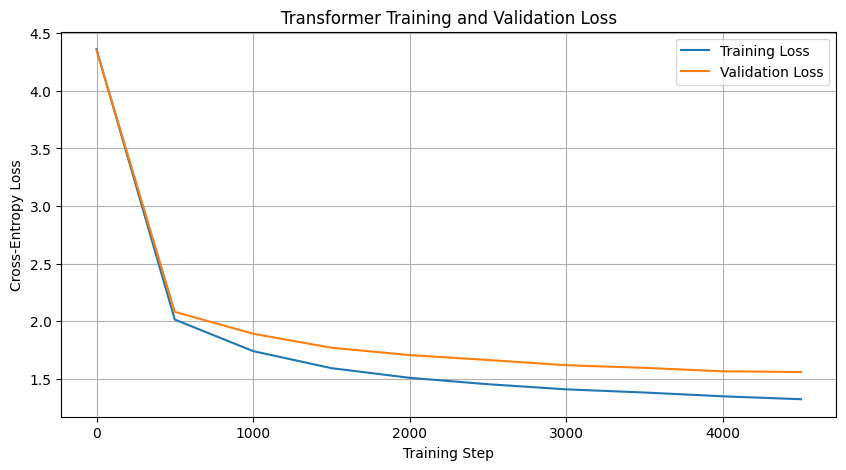

In [98]:
plt.figure(figsize=(10, 5))

plt.plot(
    steps,
    train_losses,
    label="Training Loss"
)

plt.plot(
    steps,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Training Step")
plt.ylabel("Cross-Entropy Loss")

plt.title(
    "Transformer Training and Validation Loss"
)

plt.legend()
plt.grid(True)

plt.show()

### Plot perplexity

Perplexity is:

$$PPL=e^L$$

In [99]:
train_ppl = [
    math.exp(loss)
    for loss in train_losses
]

val_ppl = [
    math.exp(loss)
    for loss in val_losses
]

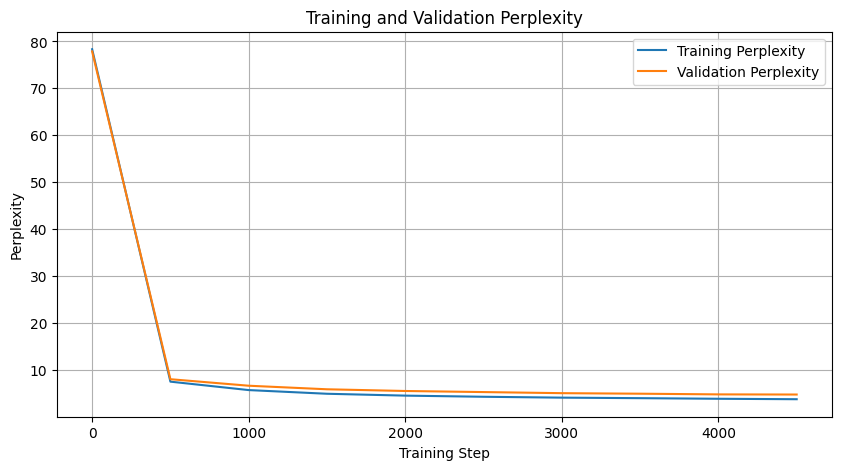

In [100]:
plt.figure(figsize=(10, 5))

plt.plot(
    steps,
    train_ppl,
    label="Training Perplexity"
)

plt.plot(
    steps,
    val_ppl,
    label="Validation Perplexity"
)

plt.xlabel("Training Step")
plt.ylabel("Perplexity")

plt.title(
    "Training and Validation Perplexity"
)

plt.legend()
plt.grid(True)

plt.show()

### Save the plots

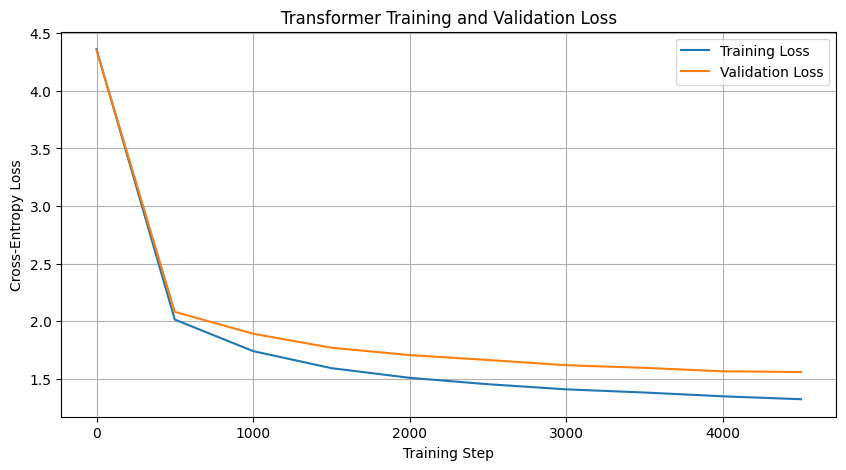

In [101]:
plt.figure(figsize=(10, 5))

plt.plot(
    steps,
    train_losses,
    label="Training Loss"
)

plt.plot(
    steps,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Training Step")
plt.ylabel("Cross-Entropy Loss")
plt.title("Transformer Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.savefig(
    "training_loss.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

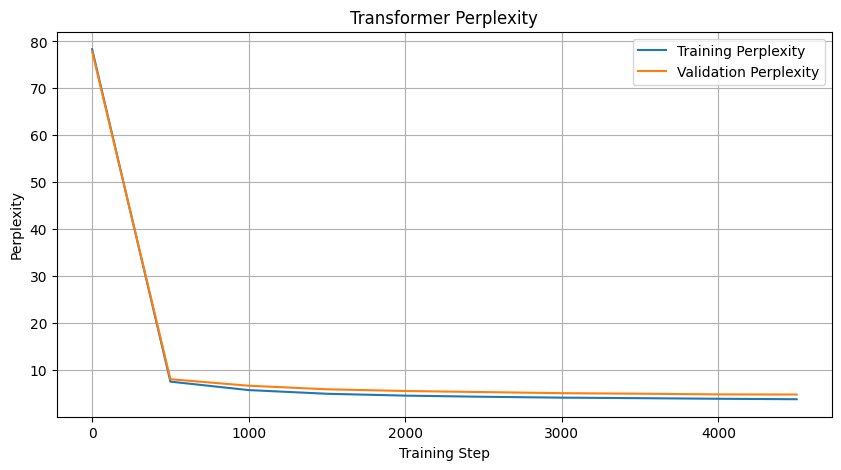

In [102]:
plt.figure(figsize=(10, 5))

plt.plot(
    steps,
    train_ppl,
    label="Training Perplexity"
)

plt.plot(
    steps,
    val_ppl,
    label="Validation Perplexity"
)

plt.xlabel("Training Step")
plt.ylabel("Perplexity")
plt.title("Transformer Perplexity")

plt.legend()
plt.grid(True)

plt.savefig(
    "perplexity.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### Attention visualization

In [103]:
prompt = "ROMEO:"

context = torch.tensor(
    [encode(prompt)],
    dtype=torch.long,
    device=device
)

with torch.no_grad():

    logits, loss, attention_maps = model(
        context
    )

print("Number of layers:", len(attention_maps))

for i, attention_map in enumerate(attention_maps):

    print(
        f"Layer {i+1}:",
        attention_map.shape
    )

Number of layers: 4
Layer 1: torch.Size([1, 4, 6, 6])
Layer 2: torch.Size([1, 4, 6, 6])
Layer 3: torch.Size([1, 4, 6, 6])
Layer 4: torch.Size([1, 4, 6, 6])


### Visualize Layer 1, Head 1

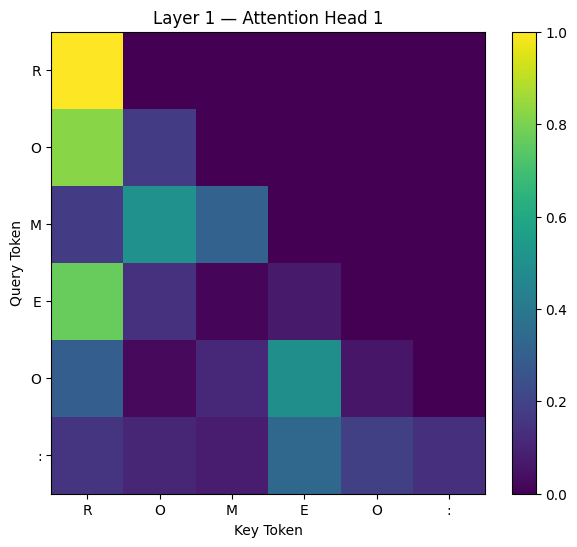

In [104]:
attention = attention_maps[0][0, 0]

plt.figure(figsize=(7, 6))

plt.imshow(
    attention.cpu().numpy(),
    aspect="auto"
)

tokens = list(prompt)

plt.xticks(
    range(len(tokens)),
    tokens
)

plt.yticks(
    range(len(tokens)),
    tokens
)

plt.xlabel("Key Token")
plt.ylabel("Query Token")

plt.title(
    "Layer 1 — Attention Head 1"
)

plt.colorbar()

plt.show()

### Use a longer prompt

In [105]:
prompt = "ROMEO: What is this love?"

context = torch.tensor(
    [encode(prompt)],
    dtype=torch.long,
    device=device
)

with torch.no_grad():

    logits, loss, attention_maps = model(
        context
    )

print("Sequence length:", context.shape[1])

Sequence length: 25


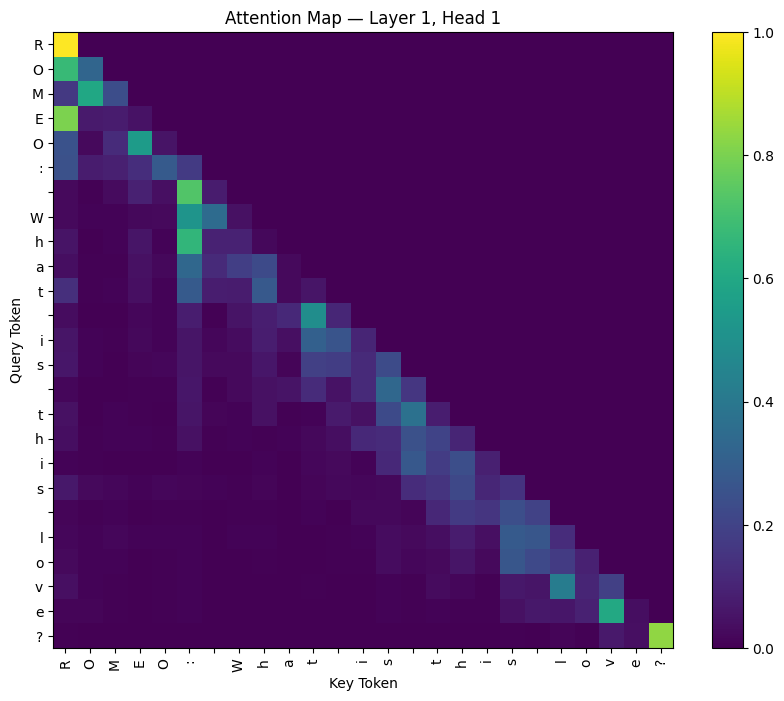

In [108]:
layer = 0
head = 0

attention = attention_maps[layer][0, head]

tokens = list(prompt)

plt.figure(figsize=(10, 8))

plt.imshow(
    attention.cpu().numpy(),
    aspect="auto"
)

plt.xticks(
    range(len(tokens)),
    tokens,
    rotation=90
)

plt.yticks(
    range(len(tokens)),
    tokens
)

plt.xlabel("Key Token")
plt.ylabel("Query Token")

plt.title(
    f"Attention Map — Layer {layer+1}, Head {head+1}"
)

plt.colorbar()

plt.show()

### Visualize all heads in one layer

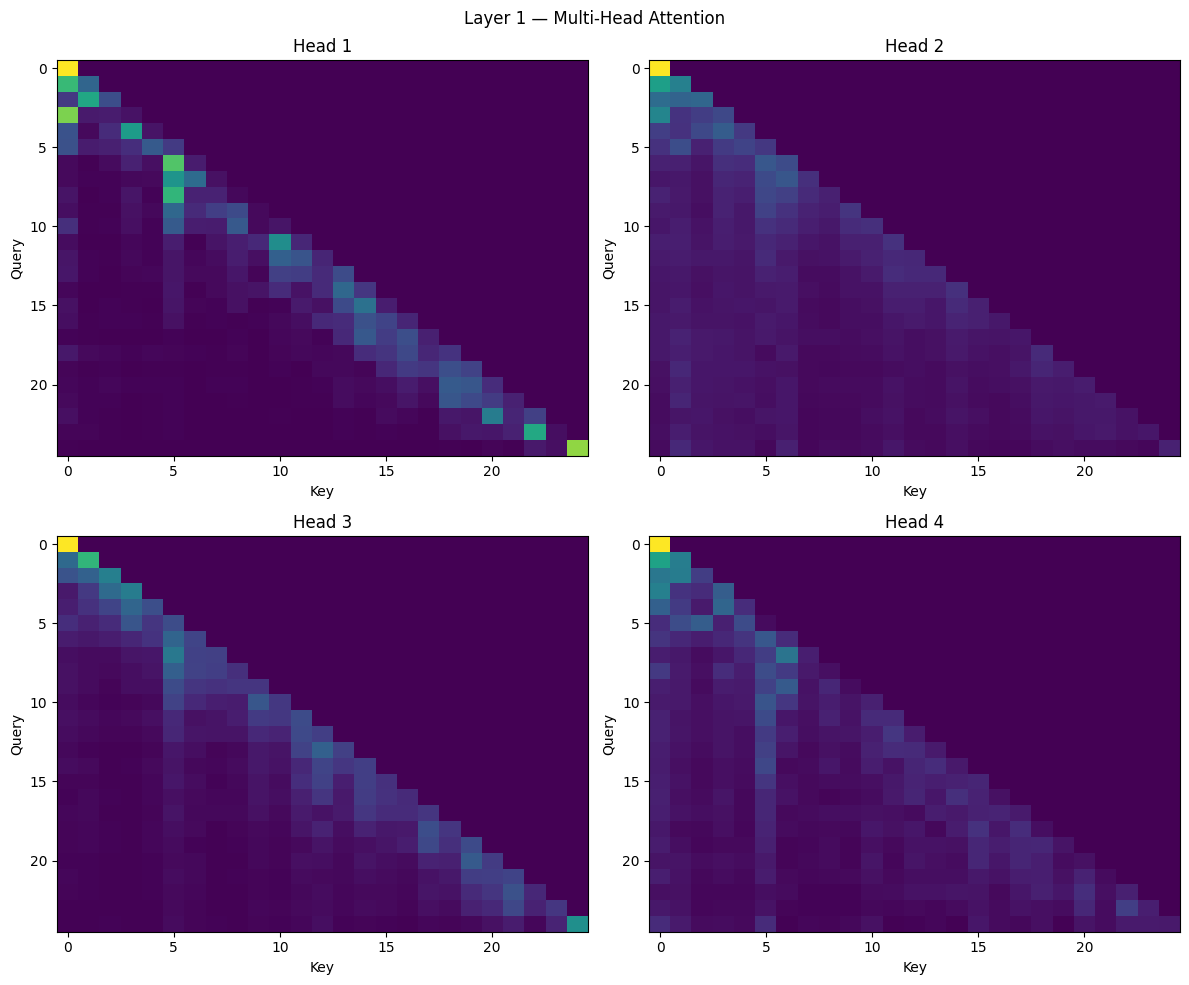

In [109]:
layer = 0

fig = plt.figure(figsize=(12, 10))

for head in range(num_heads):

    attention = attention_maps[layer][0, head]

    ax = fig.add_subplot(2, 2, head + 1)

    ax.imshow(
        attention.cpu().numpy(),
        aspect="auto"
    )

    ax.set_title(
        f"Head {head + 1}"
    )

    ax.set_xlabel("Key")
    ax.set_ylabel("Query")

plt.suptitle(
    "Layer 1 — Multi-Head Attention"
)

plt.tight_layout()

plt.show()

### Visualize the final layer

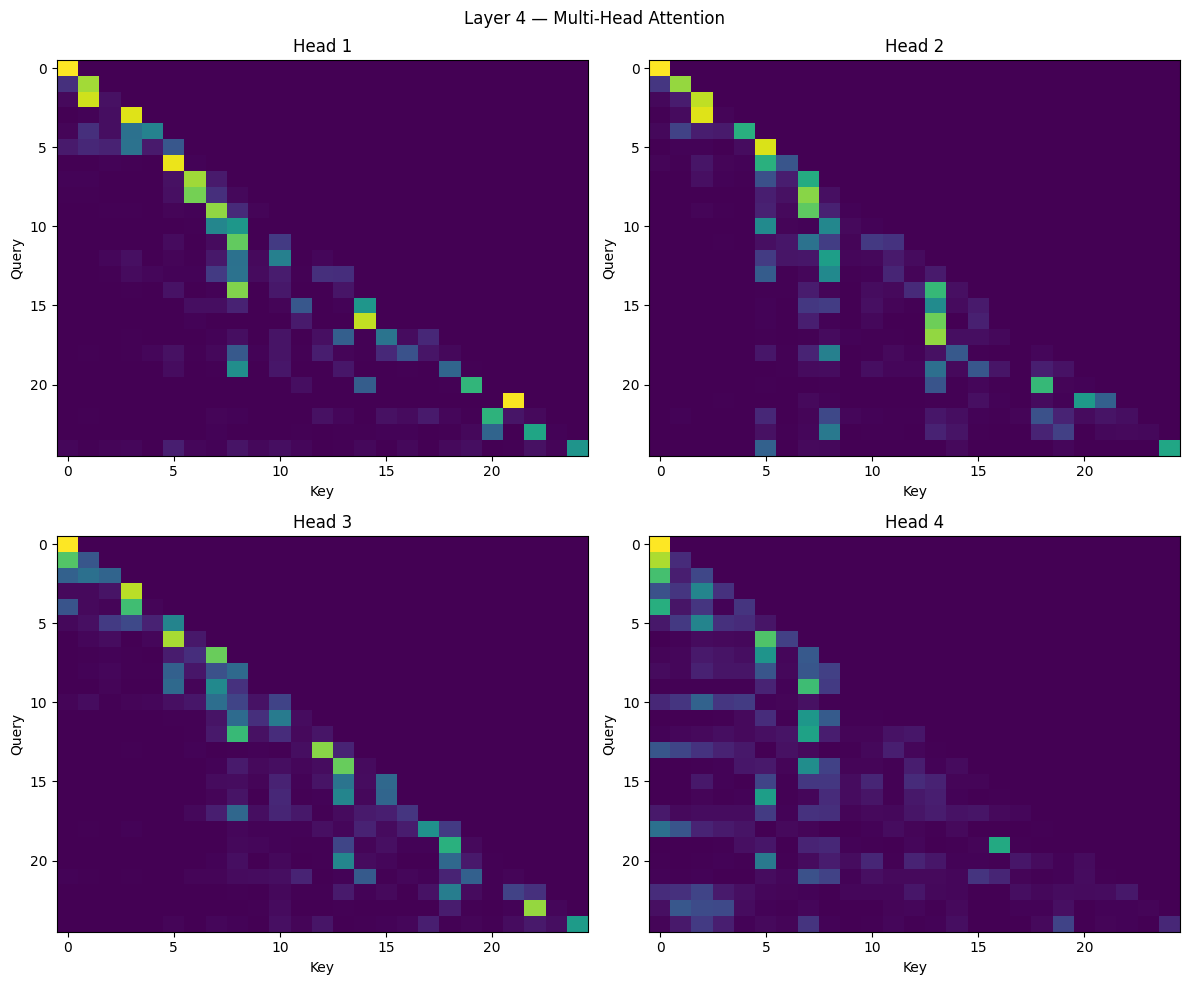

In [110]:
layer = num_layers - 1

fig = plt.figure(figsize=(12, 10))

for head in range(num_heads):

    attention = attention_maps[layer][0, head]

    ax = fig.add_subplot(2, 2, head + 1)

    ax.imshow(
        attention.cpu().numpy(),
        aspect="auto"
    )

    ax.set_title(
        f"Head {head + 1}"
    )

    ax.set_xlabel("Key")
    ax.set_ylabel("Query")

plt.suptitle(
    f"Layer {num_layers} — Multi-Head Attention"
)

plt.tight_layout()

plt.show()

    Early layers
        ↓
    More local/token-level relationships

    Later layers
        ↓
    More contextual relationships

### Quantify attention to previous positions

In [111]:
for layer_idx, attention_map in enumerate(attention_maps):

    # Average over batch and heads
    avg_attention = attention_map.mean(
        dim=(0, 1)
    )

    # Ignore diagonal
    lower_triangle = torch.tril(
        avg_attention,
        diagonal=-1
    )

    previous_attention = (
        lower_triangle.sum()
        /
        (lower_triangle != 0).sum()
    )

    print(
        f"Layer {layer_idx + 1}: "
        f"Average previous-token attention = "
        f"{previous_attention.item():.4f}"
    )

Layer 1: Average previous-token attention = 0.0677
Layer 2: Average previous-token attention = 0.0662
Layer 3: Average previous-token attention = 0.0639
Layer 4: Average previous-token attention = 0.0661


### Ablation experiment

In [112]:
model_2layer = TransformerLanguageModel(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=num_heads,
    d_ff=d_ff,
    num_layers=2,
    max_len=block_size,
    dropout=dropout
).to(device)

print(
    "2-layer parameters:",
    sum(
        p.numel()
        for p in model_2layer.parameters()
        if p.requires_grad
    )
)

2-layer parameters: 1611329


In [113]:
print(
    "4-layer parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)

4-layer parameters: 3188801


### Quick training for the 2-layer model

In [114]:
ablation_optimizer = torch.optim.AdamW(
    model_2layer.parameters(),
    lr=learning_rate,
    weight_decay=0.01
)

ablation_iters = 1000
ablation_eval_interval = 250

In [115]:
ablation_train_losses = []
ablation_val_losses = []

for iteration in range(ablation_iters):

    if iteration % ablation_eval_interval == 0:

        model_2layer.eval()

        losses = {
            "train": [],
            "val": []
        }

        with torch.no_grad():

            for split in ["train", "val"]:

                for _ in range(25):

                    X, Y = get_batch(split)

                    _, loss, _ = model_2layer(X, Y)

                    losses[split].append(
                        loss.item()
                    )

        train_loss = sum(
            losses["train"]
        ) / len(losses["train"])

        val_loss = sum(
            losses["val"]
        ) / len(losses["val"])

        ablation_train_losses.append(
            train_loss
        )

        ablation_val_losses.append(
            val_loss
        )

        print(
            f"Step {iteration:4d} | "
            f"Train: {train_loss:.4f} | "
            f"Val: {val_loss:.4f}"
        )

        model_2layer.train()

    X, Y = get_batch("train")

    _, loss, _ = model_2layer(X, Y)

    ablation_optimizer.zero_grad(
        set_to_none=True
    )

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model_2layer.parameters(),
        max_norm=1.0
    )

    ablation_optimizer.step()

Step    0 | Train: 4.2655 | Val: 4.2682
Step  250 | Train: 2.3190 | Val: 2.3258
Step  500 | Train: 2.1120 | Val: 2.1495
Step  750 | Train: 1.9506 | Val: 2.0537


### Compare the models

In [116]:
model.eval()
model_2layer.eval()

final_4layer = estimate_loss()

print(
    "4-layer validation loss:",
    final_4layer["val"]
)

4-layer validation loss: 1.54753711104393


In [117]:
@torch.no_grad()
def evaluate_model(model_to_evaluate):

    model_to_evaluate.eval()

    losses = []

    for _ in range(100):

        X, Y = get_batch("val")

        _, loss, _ = model_to_evaluate(
            X,
            Y
        )

        losses.append(loss.item())

    return sum(losses) / len(losses)

In [118]:
loss_2layer = evaluate_model(
    model_2layer
)

loss_4layer = evaluate_model(
    model
)

print("================================")
print("DEPTH ABLATION")
print("================================")

print(
    f"2-layer Validation Loss: "
    f"{loss_2layer:.4f}"
)

print(
    f"4-layer Validation Loss: "
    f"{loss_4layer:.4f}"
)

print(
    f"2-layer Perplexity: "
    f"{math.exp(loss_2layer):.2f}"
)

print(
    f"4-layer Perplexity: "
    f"{math.exp(loss_4layer):.2f}"
)

DEPTH ABLATION
2-layer Validation Loss: 1.9688
4-layer Validation Loss: 1.5498
2-layer Perplexity: 7.16
4-layer Perplexity: 4.71


### Create the final results table

In [119]:
print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

print(
    f"{'Model':<15}"
    f"{'Layers':<10}"
    f"{'Parameters':<15}"
    f"{'Val Loss':<15}"
    f"{'Val PPL':<15}"
)

print("-" * 70)

params_2 = sum(
    p.numel()
    for p in model_2layer.parameters()
    if p.requires_grad
)

params_4 = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"{'Transformer':<15}"
    f"{2:<10}"
    f"{params_2:<15,}"
    f"{loss_2layer:<15.4f}"
    f"{math.exp(loss_2layer):<15.2f}"
)

print(
    f"{'Transformer':<15}"
    f"{4:<10}"
    f"{params_4:<15,}"
    f"{loss_4layer:<15.4f}"
    f"{math.exp(loss_4layer):<15.2f}"
)

FINAL MODEL COMPARISON
Model          Layers    Parameters     Val Loss       Val PPL        
----------------------------------------------------------------------
Transformer    2         1,611,329      1.9688         7.16           
Transformer    4         3,188,801      1.5498         4.71           


### Save the attention visualization

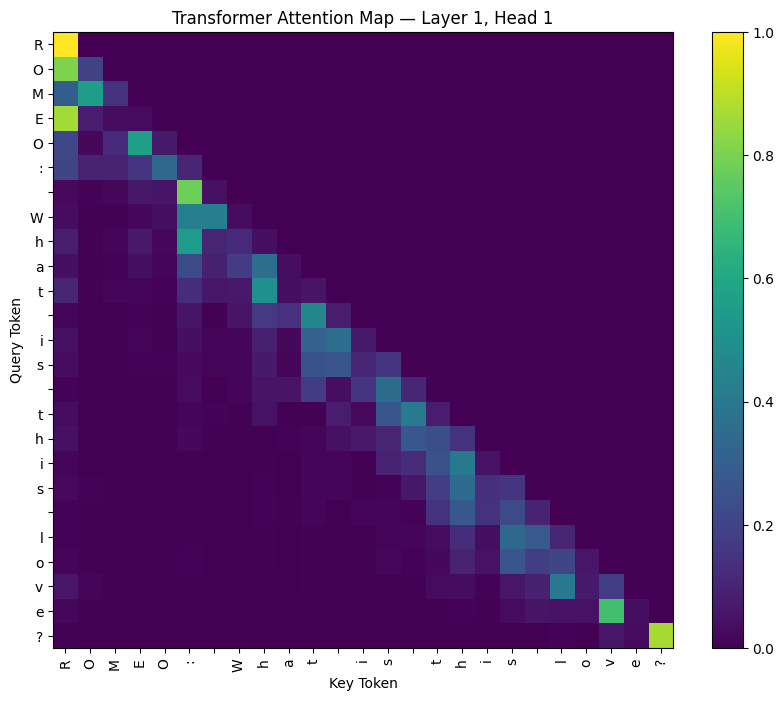

In [120]:
prompt = "ROMEO: What is this love?"

context = torch.tensor(
    [encode(prompt)],
    dtype=torch.long,
    device=device
)

with torch.no_grad():

    _, _, attention_maps = model(context)

layer = 0
head = 0

attention = attention_maps[layer][0, head]

plt.figure(figsize=(10, 8))

plt.imshow(
    attention.cpu().numpy(),
    aspect="auto"
)

tokens = list(prompt)

plt.xticks(
    range(len(tokens)),
    tokens,
    rotation=90
)

plt.yticks(
    range(len(tokens)),
    tokens
)

plt.xlabel("Key Token")
plt.ylabel("Query Token")

plt.title(
    "Transformer Attention Map — Layer 1, Head 1"
)

plt.colorbar()

plt.savefig(
    "attention_map.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()